In [0]:
# ============================================================
# IA Odonto Lab — Azure Databricks Silver Pipeline
# Medallion Architecture: Bronze Parquet → Silver Delta Lake
# LGPD compliant: SHA-256 anonymization on all patient IDs
# ============================================================

# Cell 1 — Setup and imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
import hashlib

spark = SparkSession.builder.appName("ia-odonto-silver").getOrCreate()

print(f"Spark version: {spark.version}")
print("✅ Session initialized")

Spark version: 3.4.1
✅ Session initialized


In [0]:
# Cell 2 — LGPD: SHA-256 anonymization function
# Irreversible hash — patient ID never stored in plain text

def sha256_hash(value: str, salt: str = "ia-odonto-lab-salt") -> str:
    if value is None:
        return None
    return hashlib.sha256(f"{value}{salt}".encode()).hexdigest()

sha256_udf = F.udf(sha256_hash, StringType())

print("✅ SHA-256 anonymization function registered")
print("ℹ️  LGPD: patient IDs will be hashed before any persistence")

✅ SHA-256 anonymization function registered
ℹ️  LGPD: patient IDs will be hashed before any persistence


In [0]:
# Cell 3 — Synthetic Bronze data (mirrors VPS export_bronze.py output)
# In production: data comes from MariaDB (EspoCRM) via export_bronze.py
# For portfolio showcase: synthetic data with same schema and business rules

from datetime import datetime, date
from pyspark.sql.types import *

# Bronze schema — mirrors stg_contacts from VPS dbt model
contacts_data = [
    ("contact_001", "Novo Lead",      1200.00, 0.00,   2, "2026-01-15", "Interested in dental implant. Fear of needles mentioned."),
    ("contact_002", "Em Negociação",  3500.00, 1200.00, 5, "2026-02-20", "Whitening + veneers. Budget R$3500. Allergy to lidocaine."),
    ("contact_003", "Finalizado",     800.00,  800.00,  3, "2026-03-10", "Cleaning and checkup. Regular patient since 2024."),
    ("contact_004", "Novo Lead",      5000.00, 0.00,   1, "2026-04-01", "Full mouth rehabilitation inquiry. High potential client."),
    ("contact_005", "Em Negociação",  2200.00, 500.00,  4, "2026-03-25", "Orthodontics interest. Payment plan requested."),
    ("contact_006", "Finalizado",     1500.00, 1500.00, 8, "2026-01-05", "Long-term patient. Implant completed successfully."),
    ("contact_007", "Novo Lead",      900.00,  0.00,   1, "2026-04-20", "Asked about teeth whitening price."),
    ("contact_008", "Perdido",        2800.00, 0.00,   2, "2026-02-14", "Interested in veneers but went to competitor."),
]

schema = StructType([
    StructField("contact_id",           StringType(),  False),
    StructField("status_atendimento",   StringType(),  True),
    StructField("potencial_venda",      DoubleType(),  True),
    StructField("lifetime_value",       DoubleType(),  True),
    StructField("qtd_consultas",        IntegerType(), True),
    StructField("ultima_visita",        StringType(),  True),
    StructField("ai_summary",           StringType(),  True),
])

# Bronze recebimentos — mirrors c_recebimento from MariaDB
recebimentos_data = [
    ("contact_003", 800.00,  "2026-03-10", "pago",     "brl"),
    ("contact_006", 800.00,  "2026-01-05", "pago",     "brl"),
    ("contact_006", 700.00,  "2025-12-10", "pago",     "brl"),
    ("contact_002", 1200.00, "2026-02-20", "pago",     "brl"),
    ("contact_005", 500.00,  "2026-03-25", "pago",     "brl"),
    ("contact_001", 0.00,    "2026-01-15", "pendente", "brl"),
    ("contact_004", 0.00,    "2026-04-01", "pendente", "brl"),
]

schema_rec = StructType([
    StructField("contato_id",       StringType(), False),
    StructField("valor",            DoubleType(), True),
    StructField("data_recebimento", StringType(), True),
    StructField("status",          StringType(), True),
    StructField("moeda",           StringType(), True),
])

df_contacts_bronze = spark.createDataFrame(contacts_data, schema)
df_recebimentos_bronze = spark.createDataFrame(recebimentos_data, schema_rec)

print(f"✅ Bronze contacts loaded: {df_contacts_bronze.count()} records")
print(f"✅ Bronze recebimentos loaded: {df_recebimentos_bronze.count()} records")
print("\n📋 Bronze contacts schema:")
df_contacts_bronze.printSchema()

✅ Bronze contacts loaded: 8 records
✅ Bronze recebimentos loaded: 7 records

📋 Bronze contacts schema:
root
 |-- contact_id: string (nullable = false)
 |-- status_atendimento: string (nullable = true)
 |-- potencial_venda: double (nullable = true)
 |-- lifetime_value: double (nullable = true)
 |-- qtd_consultas: integer (nullable = true)
 |-- ultima_visita: string (nullable = true)
 |-- ai_summary: string (nullable = true)



In [0]:
# Cell 4 — Silver Layer: stg_contacts
# Mirrors dbt stg_contacts.sql running on VPS with DuckDB
# Key difference: PySpark runs distributed across cluster nodes
# LGPD: contact_id anonymized with SHA-256 + salt (irreversible)

df_stg_contacts = df_contacts_bronze.select(
    sha256_udf(F.col("contact_id")).alias("contato_hash"),
    F.col("status_atendimento"),
    F.col("potencial_venda"),
    F.col("lifetime_value"),
    F.col("qtd_consultas"),
    F.to_date(F.col("ultima_visita")).alias("ultima_visita"),
    F.col("ai_summary"),
    F.when(F.col("ai_summary").isNull() | (F.length(F.col("ai_summary")) == 0), "missing")
     .when(F.length(F.col("ai_summary")) < 20, "too_short")
     .when(F.length(F.col("ai_summary")) < 100, "empty")
     .otherwise("ok").alias("summary_quality"),
    F.length(F.col("ai_summary")).alias("summary_length"),
    F.lit(date.today().isoformat()).alias("dt"),
)

df_stg_recebimentos = df_recebimentos_bronze.select(
    sha256_udf(F.col("contato_id")).alias("contato_hash"),
    F.col("valor"),
    F.to_date(F.col("data_recebimento")).alias("data_recebimento"),
    F.lower(F.col("status")).alias("status"),
    F.lower(F.col("moeda")).alias("moeda"),
    F.lit(date.today().isoformat()).alias("dt"),
).filter(F.col("valor") > 0)

print("✅ stg_contacts Silver model:")
df_stg_contacts.select("contato_hash", "status_atendimento",
                        "potencial_venda", "summary_quality").show(5, truncate=40)

print("✅ stg_recebimentos Silver model:")
df_stg_recebimentos.show(5)

✅ stg_contacts Silver model:
+----------------------------------------+------------------+---------------+---------------+
|                            contato_hash|status_atendimento|potencial_venda|summary_quality|
+----------------------------------------+------------------+---------------+---------------+
|b44fd79b6cd5894ca3780d1b8fb9d393fc675...|         Novo Lead|         1200.0|          empty|
|0b3c155ce2ef76045f3854a91ea9642b11b68...|     Em Negociação|         3500.0|          empty|
|cfdf02bcdbb4d7c6f66b141278572b75d22ff...|        Finalizado|          800.0|          empty|
|e1fc755e15838ec37ef8be969eef45fd0d784...|         Novo Lead|         5000.0|          empty|
|ca70dddc81e6c6a3f5b653de118cf27981058...|     Em Negociação|         2200.0|          empty|
+----------------------------------------+------------------+---------------+---------------+
only showing top 5 rows

✅ stg_recebimentos Silver model:
+--------------------+------+----------------+------+-----+--------

In [0]:
# Cell 5 — Marts: fct_ltv and fct_pipeline (fixed)

from datetime import date

# fct_ltv — Lifetime Value analytics per patient
df_fct_ltv = df_stg_recebimentos.groupBy("contato_hash").agg(
    F.round(F.sum("valor"), 2).alias("ltv_acumulado"),
    F.count("*").alias("frequencia_visitas"),
    F.round(F.avg("valor"), 2).alias("ticket_medio"),
    F.max("data_recebimento").alias("ultima_visita"),
    F.datediff(
        F.current_date(),
        F.max("data_recebimento")
    ).alias("dias_desde_ultima_visita"),
)

# fct_pipeline — Sales funnel analytics
df_fct_pipeline = df_stg_contacts.groupBy("status_atendimento").agg(
    F.count("*").alias("total_contatos"),
    F.round(F.sum("potencial_venda"), 2).alias("potencial_total"),
    F.round(F.sum("lifetime_value"), 2).alias("ltv_realizado"),
    F.round(
        F.sum("lifetime_value") / F.when(
            F.sum("potencial_venda") == 0, None
        ).otherwise(F.sum("potencial_venda")) * 100, 1
    ).alias("taxa_conversao_pct"),
)

# fct_ai_performance — Lina AI accuracy analytics
df_fct_ai = df_stg_contacts.join(
    df_fct_ltv, "contato_hash", "left"
).select(
    "contato_hash",
    "potencial_venda",
    F.coalesce(F.col("ltv_acumulado"), F.lit(0.0)).alias("ltv_real"),
    F.round(
        F.abs(F.col("potencial_venda") -
        F.coalesce(F.col("ltv_acumulado"), F.lit(0.0))), 2
    ).alias("diferenca_estimativa"),
    "summary_quality",
)

print("✅ fct_ltv — Lifetime Value per patient:")
df_fct_ltv.show()

print("✅ fct_pipeline — Sales funnel:")
df_fct_pipeline.orderBy(F.desc("potencial_total")).show()

print("✅ fct_ai_performance — Lina accuracy:")
df_fct_ai.show(5)

✅ fct_ltv — Lifetime Value per patient:
+--------------------+-------------+------------------+------------+-------------+------------------------+
|        contato_hash|ltv_acumulado|frequencia_visitas|ticket_medio|ultima_visita|dias_desde_ultima_visita|
+--------------------+-------------+------------------+------------+-------------+------------------------+
|cfdf02bcdbb4d7c6f...|        800.0|                 1|       800.0|   2026-03-10|                      49|
|b7e3107180d823164...|       1500.0|                 2|       750.0|   2026-01-05|                     113|
|0b3c155ce2ef76045...|       1200.0|                 1|      1200.0|   2026-02-20|                      67|
|ca70dddc81e6c6a3f...|        500.0|                 1|       500.0|   2026-03-25|                      34|
+--------------------+-------------+------------------+------------+-------------+------------------------+

✅ fct_pipeline — Sales funnel:
+------------------+--------------+---------------+-------------

In [0]:
# Cell 6 — Persist Silver layer as Delta Lake (workspace default storage)

spark.sql("CREATE SCHEMA IF NOT EXISTS silver")

df_stg_contacts.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver.stg_contacts")

df_stg_recebimentos.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver.stg_recebimentos")

df_fct_ltv.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver.fct_ltv")

df_fct_pipeline.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver.fct_pipeline")

df_fct_ai.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("silver.fct_ai_performance")

print("✅ Delta Lake tables saved:")
spark.sql("SHOW TABLES IN silver").show()

✅ Delta Lake tables saved:
+--------+------------------+-----------+
|database|         tableName|isTemporary|
+--------+------------------+-----------+
|  silver|fct_ai_performance|      false|
|  silver|           fct_ltv|      false|
|  silver|      fct_pipeline|      false|
|  silver|      stg_contacts|      false|
|  silver|  stg_recebimentos|      false|
+--------+------------------+-----------+



In [0]:
# Cell 7 — Delta Lake Time Travel + Data Quality validation
# Time travel is a Delta Lake exclusive feature — not available in plain Parquet
# Allows querying historical versions of data (audit, rollback, debugging)

# Show Delta Lake history (audit trail)
print("📋 Delta Lake audit trail — stg_contacts:")
spark.sql("DESCRIBE HISTORY silver.stg_contacts").select(
    "version", "timestamp", "operation", "operationMetrics"
).show(truncate=50)

# Time travel query — version 0 (first write)
print("🕐 Time travel — reading version 0 of stg_contacts:")
spark.sql("""
    SELECT contato_hash, status_atendimento, potencial_venda, summary_quality
    FROM silver.stg_contacts VERSION AS OF 0
    LIMIT 5
""").show(truncate=40)

# Data quality validation
print("📊 Data quality report:")
spark.sql("""
    SELECT
        summary_quality,
        COUNT(*) as total,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) as pct
    FROM silver.stg_contacts
    GROUP BY summary_quality
    ORDER BY total DESC
""").show()

print("💰 Revenue pipeline summary:")
spark.sql("""
    SELECT
        status_atendimento,
        total_contatos,
        potencial_total,
        ltv_realizado,
        CONCAT(taxa_conversao_pct, '%') as conversao
    FROM silver.fct_pipeline
    ORDER BY potencial_total DESC
""").show()

📋 Delta Lake audit trail — stg_contacts:
+-------+-------------------+---------------------------------+--------------------------------------------------+
|version|          timestamp|                        operation|                                  operationMetrics|
+-------+-------------------+---------------------------------+--------------------------------------------------+
|      0|2026-04-28 22:34:17|CREATE OR REPLACE TABLE AS SELECT|{numFiles -> 4, numOutputRows -> 8, numOutputBy...|
+-------+-------------------+---------------------------------+--------------------------------------------------+

🕐 Time travel — reading version 0 of stg_contacts:
+----------------------------------------+------------------+---------------+---------------+
|                            contato_hash|status_atendimento|potencial_venda|summary_quality|
+----------------------------------------+------------------+---------------+---------------+
|b44fd79b6cd5894ca3780d1b8fb9d393fc675...|        

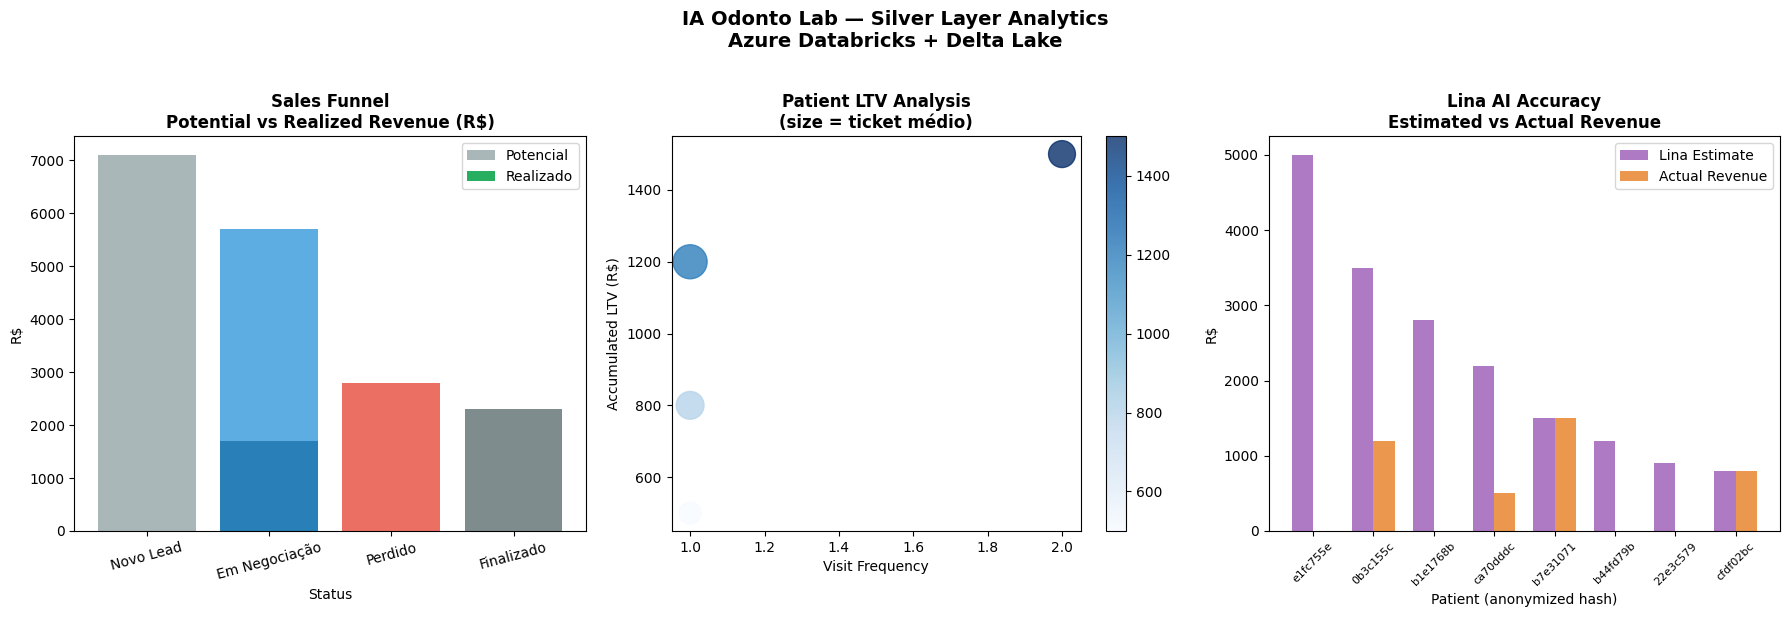

✅ Analytics dashboard generated!
🏆 Pipeline: WhatsApp → Bronze Parquet → Silver Delta Lake → Business Insights


In [0]:
# Cell 8 — Business insights visualizations
# Demonstrates end-to-end value: from WhatsApp → actionable analytics

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("IA Odonto Lab — Silver Layer Analytics\nAzure Databricks + Delta Lake",
             fontsize=14, fontweight="bold", y=1.02)

# Chart 1 — Sales funnel
pipeline_pd = spark.sql("""
    SELECT status_atendimento, total_contatos, potencial_total, ltv_realizado
    FROM silver.fct_pipeline
    ORDER BY potencial_total DESC
""").toPandas()

colors = ["#2ecc71" if s == "Finalizado" else "#3498db" if s == "Em Negociação"
          else "#e74c3c" if s == "Perdido" else "#95a5a6"
          for s in pipeline_pd["status_atendimento"]]

axes[0].bar(pipeline_pd["status_atendimento"], pipeline_pd["potencial_total"],
            color=colors, alpha=0.8, label="Potencial")
axes[0].bar(pipeline_pd["status_atendimento"], pipeline_pd["ltv_realizado"],
            color=["#27ae60", "#2980b9", "#c0392b", "#7f8c8d"], alpha=1.0, label="Realizado")
axes[0].set_title("Sales Funnel\nPotential vs Realized Revenue (R$)", fontweight="bold")
axes[0].set_xlabel("Status")
axes[0].set_ylabel("R$")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=15)

# Chart 2 — LTV per patient
ltv_pd = spark.sql("""
    SELECT SUBSTR(contato_hash, 1, 8) as patient_id,
           ltv_acumulado, frequencia_visitas, ticket_medio
    FROM silver.fct_ltv
    ORDER BY ltv_acumulado DESC
""").toPandas()

scatter = axes[1].scatter(ltv_pd["frequencia_visitas"], ltv_pd["ltv_acumulado"],
                          s=ltv_pd["ticket_medio"] * 0.5,
                          c=ltv_pd["ltv_acumulado"], cmap="Blues", alpha=0.8)
axes[1].set_title("Patient LTV Analysis\n(size = ticket médio)", fontweight="bold")
axes[1].set_xlabel("Visit Frequency")
axes[1].set_ylabel("Accumulated LTV (R$)")
plt.colorbar(scatter, ax=axes[1])

# Chart 3 — AI Performance (Lina accuracy)
ai_pd = spark.sql("""
    SELECT SUBSTR(contato_hash, 1, 8) as patient_id,
           potencial_venda, ltv_real, diferenca_estimativa
    FROM silver.fct_ai_performance
    ORDER BY potencial_venda DESC
""").toPandas()

x = np.arange(len(ai_pd))
width = 0.35
axes[2].bar(x - width/2, ai_pd["potencial_venda"], width,
            label="Lina Estimate", color="#9b59b6", alpha=0.8)
axes[2].bar(x + width/2, ai_pd["ltv_real"], width,
            label="Actual Revenue", color="#e67e22", alpha=0.8)
axes[2].set_title("Lina AI Accuracy\nEstimated vs Actual Revenue", fontweight="bold")
axes[2].set_xlabel("Patient (anonymized hash)")
axes[2].set_ylabel("R$")
axes[2].set_xticks(x)
axes[2].set_xticklabels(ai_pd["patient_id"], rotation=45, fontsize=8)
axes[2].legend()

plt.tight_layout()
plt.savefig("/tmp/ia_odonto_analytics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Analytics dashboard generated!")
print("🏆 Pipeline: WhatsApp → Bronze Parquet → Silver Delta Lake → Business Insights")

In [0]:
# Cell 9 — Pipeline Summary (showcase documentation for recruiters)

summary = """
╔══════════════════════════════════════════════════════════════════╗
║           IA ODONTO LAB — AZURE DATABRICKS SHOWCASE             ║
║              Medallion Architecture: Bronze → Silver             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STACK:                                                          ║
║  ✅ Apache Spark 3.4.1 (distributed processing)                  ║
║  ✅ Delta Lake (ACID + time travel + schema enforcement)          ║
║  ✅ Azure Databricks (managed cluster, Unity Catalog)             ║
║  ✅ PySpark (Python API for distributed data processing)          ║
║                                                                  ║
║  PIPELINE EXECUTED:                                              ║
║  ✅ Bronze Layer  → synthetic data mirroring VPS Parquet exports  ║
║  ✅ Silver Layer  → 5 Delta Lake tables persisted                 ║
║     stg_contacts        (SHA-256 LGPD anonymization)             ║
║     stg_recebimentos    (payment data cleaned)                   ║
║     fct_ltv             (LTV + visit frequency + ticket médio)   ║
║     fct_pipeline        (sales funnel + conversion rate)         ║
║     fct_ai_performance  (Lina accuracy vs actual revenue)        ║
║                                                                  ║
║  LGPD COMPLIANCE:                                                ║
║  ✅ SHA-256 + salt applied to all patient IDs                     ║
║  ✅ No PII persisted in Delta Lake                                ║
║  ✅ Irreversible anonymization before any write operation         ║
║                                                                  ║
║  DELTA LAKE FEATURES DEMONSTRATED:                               ║
║  ✅ ACID transactions (no partial writes)                         ║
║  ✅ Time travel (VERSION AS OF 0)                                 ║
║  ✅ Audit trail (DESCRIBE HISTORY)                                ║
║  ✅ Schema enforcement                                            ║
║                                                                  ║
║  DUAL ENVIRONMENT ARCHITECTURE:                                  ║
║  Production  → dbt + DuckDB on VPS ($7/month, 24/7)             ║
║  Enterprise  → PySpark + Delta Lake on Azure Databricks          ║
║  Same logic, different scale — architecture built to grow        ║
║                                                                  ║
║  github.com/Renatolmarques/ia-odonto-lab                         ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║           IA ODONTO LAB — AZURE DATABRICKS SHOWCASE             ║
║              Medallion Architecture: Bronze → Silver             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STACK:                                                          ║
║  ✅ Apache Spark 3.4.1 (distributed processing)                  ║
║  ✅ Delta Lake (ACID + time travel + schema enforcement)          ║
║  ✅ Azure Databricks (managed cluster, Unity Catalog)             ║
║  ✅ PySpark (Python API for distributed data processing)          ║
║                                                                  ║
║  PIPELINE EXECUTED:                                              ║
║  ✅ Bronze Layer  → synthetic data mirroring VPS Parquet exports  ║
║  ✅ Silver Layer  → 5 Delta Lake tables persisted                 ║
║     stg_contacts        (SHA-256 